In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [2]:
base_path = '/Users/Simon/Documents/PhD/Projects/CausalBottleneckModels/results/id'

In [3]:
# n_samples
n_samples_lin_path = os.path.join(base_path, 'linear', 'n_samples_100_1000_10000_30000', 'results.csv')
n_samples_lin = pd.read_csv(n_samples_lin_path, index_col=0)

In [4]:
# d_macro
d_macro_lin_path = os.path.join(base_path, 'linear', 'd_macro_3_5_10_20_100', 'results.npy')
d_macro_lin_npy = np.load(d_macro_lin_path)
d_macro_lin = pd.DataFrame({'d_macro': np.squeeze(np.repeat([3, 5, 10, 20, 100], 5)), 'r2': np.squeeze(np.reshape(d_macro_lin_npy, [25, -1], order='F'))})

In [5]:
# d_micro
d_micro_lin_path = os.path.join(base_path, 'linear', 'd_micro_5_10_50_100_500', 'results.csv')
d_micro_lin = pd.read_csv(d_micro_lin_path, index_col=0)

In [6]:
# d_bn
d_bn_lin_path = os.path.join(base_path, 'linear', 'd_bn_5_10_50_80', 'results.csv')
d_bn_lin = pd.read_csv(d_bn_lin_path, index_col=0)

In [11]:
def plot_single_id_run(results_df, ax, nonlin=False):
    match results_df.columns[0]:
        case 'n_samples':
            x_axis = '$n$'
        case 'd_macro':
            x_axis = '$|\mathcal{V}|$'
        case 'd_micro':
            x_axis = '$d_{\mathbf{X}}$'
        case 'd_bn':
            x_axis = '$d_{\mathbf{Z}}$'

    ax = sns.barplot(ax=ax, data=results_df, x=results_df.columns[0], y='r2',
                     palette=["#4d94ff"] if not nonlin else ["#68ca75"])

    ax.set_ylim(top=1.02)

    ax.set_xlabel(x_axis)

    # ax.set_yticks([0.0, 0.25, 0.5, 0.75, 1.0])
    # ax.tick_params(direction='out', length=6, width=2, colors='k',
    #            grid_color='grey', grid_alpha=0.5)
    #
    # color_name = "grey"
    # ax.spines["top"].set_color(color_name)
    # ax.spines["bottom"].set_color(color_name)
    # ax.spines["left"].set_color(color_name)
    # ax.spines["right"].set_color(color_name)

    if not nonlin:
        ax.set_ylabel('\large Linear \n \n avg. $R^2$')
    else:
        ax.set_ylabel('\large Nonlinear \n \n avg. $R^2$')

/var/folders/3t/tsy826vs2hqbz3y19mzxzp1w0000gn/T/ipykernel_24942/931263373.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(ax=ax, data=results_df, x=results_df.columns[0], y='r2',
/var/folders/3t/tsy826vs2hqbz3y19mzxzp1w0000gn/T/ipykernel_24942/931263373.py:12: UserWarning: 
The palette list has fewer values (1) than needed (4) and will cycle, which may produce an uninterpretable plot.
  ax = sns.barplot(ax=ax, data=results_df, x=results_df.columns[0], y='r2',
/var/folders/3t/tsy826vs2hqbz3y19mzxzp1w0000gn/T/ipykernel_24942/931263373.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(ax=ax, data=results_df, x=results_df.columns[0], y='r2',
/var/folders/3t/tsy826vs2hqbz3y19

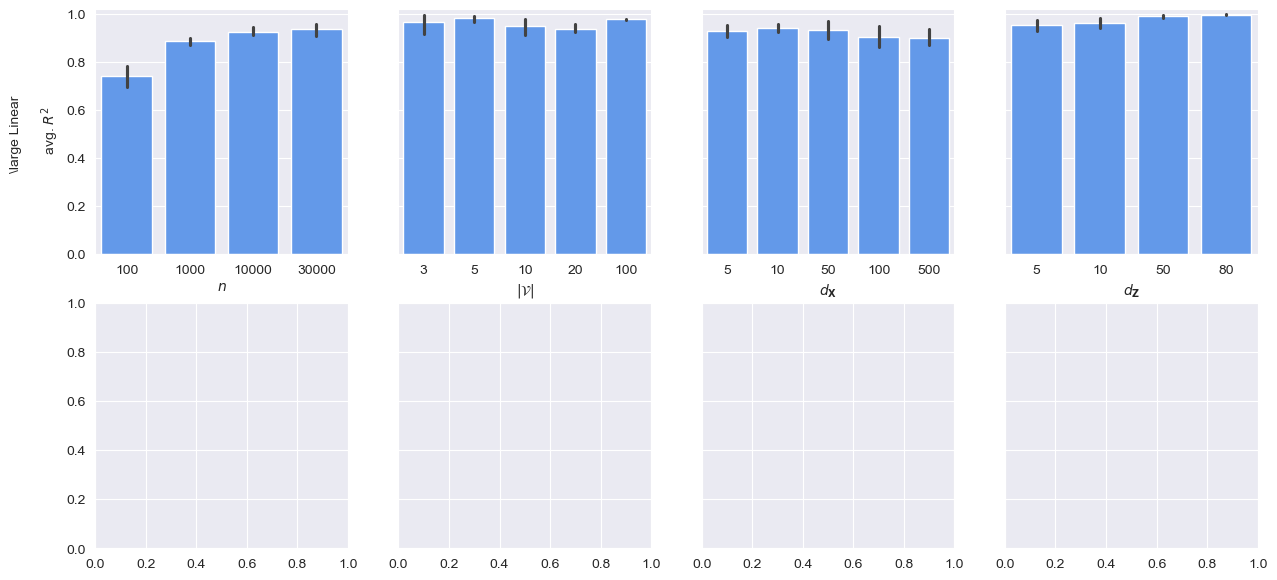

In [12]:
fig, axs = plt.subplots(2, 4, figsize=[15, 7], sharey='row')
plot_single_id_run(n_samples_lin, axs[0, 0])
plot_single_id_run(d_macro_lin, axs[0, 1])
plot_single_id_run(d_micro_lin, axs[0, 2])
plot_single_id_run(d_bn_lin, axs[0, 3])

# plot_single_id_run(n_samples_mlp, axs[1,0], nonlin=True)
# plot_single_id_run(d_macro_mlp, axs[1, 1], nonlin=True)
# plot_single_id_run(d_micro_mlp, axs[1, 2], nonlin=True)
# plot_single_id_run(d_bn_mlp, axs[1,3], nonlin=True)

fig.show()